<a href="https://colab.research.google.com/github/Nausheen1295/NorthStar-Coursework/blob/main/notebooks/Section_3_MongoDB/04_mongodb_atlas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#installing pymongo
!pip install pymongo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 19.6 MB/s eta 0:00:00


In [3]:
#importing library and loading data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

orders = pd.read_csv("/content/orders.csv")
deliveries = pd.read_csv("/content/deliveries.csv")
customers = pd.read_csv("/content/customers.csv")
drivers = pd.read_csv("/content/drivers.csv")
vehicles = pd.read_csv("/content/vehicles.csv")
hubs = pd.read_csv("/content/hubs.csv")
complaints = pd.read_csv("/content/complaints.csv")
incidents = pd.read_csv("/content/incidents.csv")
app_events = pd.read_csv("/content/app_events.csv")

orders.head()

,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag
0,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,0
1,O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,AIRPORT,Low,109.30,App,0
2,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,AIRPORT,High,33.50,Phone,0
3,O00004,C0520,Parcel,2025-01-11 17:15:00,2,RiverSide,North,Medium,10.04,App,1
4,O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,SOUTH,Low,125.58,Phone,0


In [4]:
#checking the loaded data
import os
os.listdir("/content")

['.config',
 'incidents.csv',
 'deliveries.csv',
 'customers.csv',
 'data_dictionary.csv',
 'app_events.csv',
 'orders.csv',
 'drivers.csv',
 'complaints.csv',
 'README.txt',
 'hubs.csv',
 'vehicles.csv',
 'sample_data']

In [5]:
from getpass import getpass
from pymongo import MongoClient

In [6]:
#connecting to mongodb atlas
connection_string = getpass("Paste MongoDB connection string: ")

client = MongoClient(connection_string)

db = client["northstar_db"]
collection = db["orders_operational_view"]

print(client.list_database_names())

Paste MongoDB connection string: ··········
['northstar_db', 'sample_analytics', 'sample_database', 'sample_flowerdata', 'sample_mflix', 'sample_supplies', 'admin', 'local']


In [58]:
complaint_summary = complaints.groupby("order_id").agg(
    complaint_count=("complaint_id", "count"),
    total_compensation=("compensation_amount", "sum"),
    avg_resolution_days=("resolution_days", "mean")
).reset_index()

incident_summary = incidents.groupby("delivery_id").agg(
    incident_count=("incident_id", "count"),
    high_incident_count=("severity", lambda x: (x == "High").sum()),
    avg_resolved_hours=("resolved_hours", "mean")
).reset_index()

In [7]:
#helper function for missing value
def clean_value(value):
    if pd.isna(value):
        return None
    if isinstance(value, np.integer):
        return int(value)
    if isinstance(value, np.floating):
        return float(value)
    return value

In [8]:
#create document based records
documents = []

for _, order in orders.iterrows():
    order_id = order["order_id"]
    customer_id = order["customer_id"]

    delivery_rows = deliveries[deliveries["order_id"] == order_id]
    complaint_rows = complaints[complaints["order_id"] == order_id]
    app_rows = app_events[app_events["order_id"] == order_id]
    customer_rows = customers[customers["customer_id"] == customer_id]

    customer_doc = {}
    if not customer_rows.empty:
        customer = customer_rows.iloc[0]
        customer_doc = {
            "customer_id": clean_value(customer["customer_id"]),
            "age": clean_value(customer["age"]),
            "home_zone": clean_value(customer["home_zone"]),
            "customer_type": clean_value(customer["customer_type"]),
            "loyalty_score": clean_value(customer["loyalty_score"]),
            "app_engagement_score": clean_value(customer["app_engagement_score"]),
            "preferred_channel": clean_value(customer["preferred_channel"]),
            "account_status": clean_value(customer["account_status"])
        }

    delivery_docs = []

    for _, delivery in delivery_rows.iterrows():
        driver_rows = drivers[drivers["driver_id"] == delivery["driver_id"]]
        vehicle_rows = vehicles[vehicles["vehicle_id"] == delivery["vehicle_id"]]
        hub_rows = hubs[hubs["hub_id"] == delivery["hub_id"]]
        incident_rows = incidents[incidents["delivery_id"] == delivery["delivery_id"]]

        driver_doc = {}
        if not driver_rows.empty:
            driver = driver_rows.iloc[0]
            driver_doc = {
                "driver_id": clean_value(driver["driver_id"]),
                "base_zone": clean_value(driver["base_zone"]),
                "employment_type": clean_value(driver["employment_type"]),
                "years_experience": clean_value(driver["years_experience"]),
                "training_score": clean_value(driver["training_score"]),
                "driver_rating": clean_value(driver["driver_rating"]),
                "shift_preference": clean_value(driver["shift_preference"]),
                "active_flag": clean_value(driver["active_flag"])
            }

        vehicle_doc = {}
        if not vehicle_rows.empty:
            vehicle = vehicle_rows.iloc[0]
            vehicle_doc = {
                "vehicle_id": clean_value(vehicle["vehicle_id"]),
                "vehicle_type": clean_value(vehicle["vehicle_type"]),
                "assigned_zone": clean_value(vehicle["assigned_zone"]),
                "battery_health_pct": clean_value(vehicle["battery_health_pct"]),
                "odometer_km": clean_value(vehicle["odometer_km"]),
                "maintenance_status": clean_value(vehicle["maintenance_status"]),
                "telematics_version": clean_value(vehicle["telematics_version"])
            }

        hub_doc = {}
        if not hub_rows.empty:
            hub = hub_rows.iloc[0]
            hub_doc = {
                "hub_id": clean_value(hub["hub_id"]),
                "hub_name": clean_value(hub["hub_name"]),
                "zone": clean_value(hub["zone"]),
                "hub_type": clean_value(hub["hub_type"]),
                "capacity_score": clean_value(hub["capacity_score"])
            }

        incident_docs = []
        for _, incident in incident_rows.iterrows():
            incident_docs.append({
                "incident_id": clean_value(incident["incident_id"]),
                "incident_type": clean_value(incident["incident_type"]),
                "reported_at": clean_value(incident["reported_at"]),
                "severity": clean_value(incident["severity"]),
                "resolution_status": clean_value(incident["resolution_status"]),
                "resolved_hours": clean_value(incident["resolved_hours"])
            })

        delivery_docs.append({
            "delivery_id": clean_value(delivery["delivery_id"]),
            "delivery_status": clean_value(delivery["delivery_status"]),
            "dispatch_time": clean_value(delivery["dispatch_time"]),
            "delivery_completed_at": clean_value(delivery["delivery_completed_at"]),
            "route_distance_km": clean_value(delivery["route_distance_km"]),
            "manual_route_override_count": clean_value(delivery["manual_route_override_count"]),
            "proof_of_completion_missing": clean_value(delivery["proof_of_completion_missing"]),
            "customer_rating_post_delivery": clean_value(delivery["customer_rating_post_delivery"]),
            "fuel_or_charge_cost": clean_value(delivery["fuel_or_charge_cost"]),
            "driver": driver_doc,
            "vehicle": vehicle_doc,
            "hub": hub_doc,
            "incidents": incident_docs
        })

    complaint_docs = []
    for _, complaint in complaint_rows.iterrows():
        complaint_docs.append({
            "complaint_id": clean_value(complaint["complaint_id"]),
            "complaint_type": clean_value(complaint["complaint_type"]),
            "channel": clean_value(complaint["channel"]),
            "severity": clean_value(complaint["severity"]),
            "created_at": clean_value(complaint["created_at"]),
            "status": clean_value(complaint["status"]),
            "resolution_days": clean_value(complaint["resolution_days"]),
            "compensation_amount": clean_value(complaint["compensation_amount"])
        })

    app_event_docs = []
    for _, event in app_rows.iterrows():
        app_event_docs.append({
            "event_id": clean_value(event["event_id"]),
            "event_timestamp": clean_value(event["event_timestamp"]),
            "event_type": clean_value(event["event_type"]),
            "session_id": clean_value(event["session_id"]),
            "device_type": clean_value(event["device_type"]),
            "zone_context": clean_value(event["zone_context"]),
            "api_latency_ms": clean_value(event["api_latency_ms"]),
            "success_flag": clean_value(event["success_flag"])
        })

    document = {
        "order_id": clean_value(order["order_id"]),
        "service_type": clean_value(order["service_type"]),
        "order_created_at": clean_value(order["order_created_at"]),
        "promised_window_hours": clean_value(order["promised_window_hours"]),
        "pickup_zone": clean_value(order["pickup_zone"]),
        "dropoff_zone": clean_value(order["dropoff_zone"]),
        "priority_level": clean_value(order["priority_level"]),
        "order_value": clean_value(order["order_value"]),
        "booking_channel": clean_value(order["booking_channel"]),
        "special_handling_flag": clean_value(order["special_handling_flag"]),
        "customer": customer_doc,
        "deliveries": delivery_docs,
        "complaints": complaint_docs,
        "app_events": app_event_docs
    }

    documents.append(document)

len(documents)

1250

In [9]:
#insert documents
collection.delete_many({})

result = collection.insert_many(documents)

print("Inserted documents:", len(result.inserted_ids))

Inserted documents: 1250


In [10]:
#CRUD operation 1: Create
new_order = {
    "order_id": "O99999",
    "service_type": "Business",
    "order_created_at": "2026-05-08 10:00:00",
    "promised_window_hours": 4,
    "pickup_zone": "Central",
    "dropoff_zone": "North",
    "priority_level": "High",
    "order_value": 75.50,
    "booking_channel": "App",
    "special_handling_flag": 1,
    "customer": {
        "customer_id": "C9999",
        "customer_type": "Consumer",
        "home_zone": "North"
    },
    "deliveries": [
        {
            "delivery_id": "DL99999",
            "delivery_status": "Failed",
            "manual_route_override_count": 2,
            "customer_rating_post_delivery": 2.0,
            "fuel_or_charge_cost": 15.5
        }
    ],
    "complaints": [
        {
            "complaint_id": "CP9999",
            "complaint_type": "LateDelivery",
            "severity": "High",
            "status": "Open",
            "compensation_amount": 20
        }
    ],
    "app_events": []
}

collection.insert_one(new_order)

InsertOneResult(ObjectId('6a073cae13a376ecabc19db4'), acknowledged=True)

In [11]:
#CRUD operation 2: Read
collection.find_one({"order_id": "O99999"})

{'_id': ObjectId('6a073cae13a376ecabc19db4'),
 'order_id': 'O99999',
 'service_type': 'Business',
 'order_created_at': '2026-05-08 10:00:00',
 'promised_window_hours': 4,
 'pickup_zone': 'Central',
 'dropoff_zone': 'North',
 'priority_level': 'High',
 'order_value': 75.5,
 'booking_channel': 'App',
 'special_handling_flag': 1,
 'customer': {'customer_id': 'C9999',
  'customer_type': 'Consumer',
  'home_zone': 'North'},
 'deliveries': [{'delivery_id': 'DL99999',
   'delivery_status': 'Failed',
   'manual_route_override_count': 2,
   'customer_rating_post_delivery': 2.0,
   'fuel_or_charge_cost': 15.5}],
 'complaints': [{'complaint_id': 'CP9999',
   'complaint_type': 'LateDelivery',
   'severity': 'High',
   'status': 'Open',
   'compensation_amount': 20}],
 'app_events': []}

In [12]:
#CRUD operation 3: Update
collection.update_one(
    {"order_id": "O99999"},
    {"$set": {"complaints.0.status": "Resolved"}}
)

UpdateResult({'n': 1, 'electionId': ObjectId('7fffffff000000000000025f'), 'opTime': {'ts': Timestamp(1778859183, 134), 't': 607}, 'nModified': 1, 'ok': 1.0, '$clusterTime': {'clusterTime': Timestamp(1778859183, 138), 'signature': {'hash': b'\xaaY6)x\xdd\xa0\xc5\xd6\xe3\x82J\xe8\x1a\x80\x06{\x19\xb0\x90', 'keyId': 7595642752373620752}}, 'operationTime': Timestamp(1778859183, 134), 'updatedExisting': True}, acknowledged=True)

In [13]:
#Check update
collection.find_one({"order_id": "O99999"})

{'_id': ObjectId('6a073cae13a376ecabc19db4'),
 'order_id': 'O99999',
 'service_type': 'Business',
 'order_created_at': '2026-05-08 10:00:00',
 'promised_window_hours': 4,
 'pickup_zone': 'Central',
 'dropoff_zone': 'North',
 'priority_level': 'High',
 'order_value': 75.5,
 'booking_channel': 'App',
 'special_handling_flag': 1,
 'customer': {'customer_id': 'C9999',
  'customer_type': 'Consumer',
  'home_zone': 'North'},
 'deliveries': [{'delivery_id': 'DL99999',
   'delivery_status': 'Failed',
   'manual_route_override_count': 2,
   'customer_rating_post_delivery': 2.0,
   'fuel_or_charge_cost': 15.5}],
 'complaints': [{'complaint_id': 'CP9999',
   'complaint_type': 'LateDelivery',
   'severity': 'High',
   'status': 'Resolved',
   'compensation_amount': 20}],
 'app_events': []}

In [14]:
#CRUD operation 4: Delete
collection.delete_one({"order_id": "O99999"})

DeleteResult({'n': 1, 'electionId': ObjectId('7fffffff000000000000025f'), 'opTime': {'ts': Timestamp(1778859183, 214), 't': 607}, 'ok': 1.0, '$clusterTime': {'clusterTime': Timestamp(1778859183, 214), 'signature': {'hash': b'\xaaY6)x\xdd\xa0\xc5\xd6\xe3\x82J\xe8\x1a\x80\x06{\x19\xb0\x90', 'keyId': 7595642752373620752}}, 'operationTime': Timestamp(1778859183, 214)}, acknowledged=True)

In [15]:
#Check delete
collection.find_one({"order_id": "O99999"})

In [16]:
#Find types of services available
collection.distinct("service_type")

['Business', 'Medical', 'Parcel', 'Passenger', 'Retail']

In [17]:
#Find Business service orders
Business_orders = list(collection.find(
    {"service_type": "Business"},
    {
        "_id": 0,
        "order_id": 1,
        "service_type": 1,
        "pickup_zone": 1,
        "dropoff_zone": 1,
        "priority_level": 1,
        "order_value": 1
    }
).limit(5))

Business_orders

[{'order_id': 'O00007',
  'service_type': 'Business',
  'pickup_zone': 'CENTRAL',
  'dropoff_zone': 'Airport',
  'priority_level': 'Low',
  'order_value': 76.12},
 {'order_id': 'O00012',
  'service_type': 'Business',
  'pickup_zone': 'East',
  'dropoff_zone': 'Airport',
  'priority_level': 'Medium',
  'order_value': 135.67},
 {'order_id': 'O00015',
  'service_type': 'Business',
  'pickup_zone': 'SOUTH',
  'dropoff_zone': 'East',
  'priority_level': 'High',
  'order_value': 145.58},
 {'order_id': 'O00035',
  'service_type': 'Business',
  'pickup_zone': 'north',
  'dropoff_zone': 'CENTRAL',
  'priority_level': 'Medium',
  'order_value': 209.07},
 {'order_id': 'O00044',
  'service_type': 'Business',
  'pickup_zone': 'West',
  'dropoff_zone': 'Riverside',
  'priority_level': 'Medium',
  'order_value': 61.45}]

In [18]:
#Find orders where the delivery status is Failed
failed_deliveries = list(collection.find(
    {"deliveries.delivery_status": "Failed"},
    {
        "_id": 0,
        "order_id": 1,
        "service_type": 1,
        "pickup_zone": 1,
        "dropoff_zone": 1,
        "deliveries.delivery_id": 1,
        "deliveries.delivery_status": 1,
        "deliveries.customer_rating_post_delivery": 1
    }
).limit(5))
failed_deliveries

[{'order_id': 'O00023',
  'service_type': 'Passenger',
  'pickup_zone': 'north',
  'dropoff_zone': 'north',
  'deliveries': [{'delivery_id': 'DL00831',
    'delivery_status': 'Failed',
    'customer_rating_post_delivery': 2.38}]},
 {'order_id': 'O00031',
  'service_type': 'Passenger',
  'pickup_zone': 'EAST',
  'dropoff_zone': 'AIRPORT',
  'deliveries': [{'delivery_id': 'DL00862',
    'delivery_status': 'Failed',
    'customer_rating_post_delivery': 1.41}]},
 {'order_id': 'O00033',
  'service_type': 'Retail',
  'pickup_zone': 'NORTH',
  'dropoff_zone': 'East',
  'deliveries': [{'delivery_id': 'DL00792',
    'delivery_status': 'Failed',
    'customer_rating_post_delivery': 3.2}]},
 {'order_id': 'O00035',
  'service_type': 'Business',
  'pickup_zone': 'north',
  'dropoff_zone': 'CENTRAL',
  'deliveries': [{'delivery_id': 'DL00492',
    'delivery_status': 'Failed',
    'customer_rating_post_delivery': 1.99}]},
 {'order_id': 'O00070',
  'service_type': 'Retail',
  'pickup_zone': 'Ctr',
  '

In [19]:
#Find orders with high-severity complaints
high_severity_complaints = list(collection.find(
    {"complaints.severity": "High"},
    {
        "_id": 0,
        "order_id": 1,
        "customer.customer_id": 1,
        "customer.customer_type": 1,
        "pickup_zone": 1,
        "complaints.complaint_id": 1,
        "complaints.complaint_type": 1,
        "complaints.severity": 1,
        "complaints.status": 1,
        "complaints.compensation_amount": 1
    }
).limit(5))

high_severity_complaints

[{'order_id': 'O00007',
  'pickup_zone': 'CENTRAL',
  'customer': {'customer_id': 'C0001', 'customer_type': 'SME'},
  'complaints': [{'complaint_id': 'CP0096',
    'complaint_type': 'AppIssue',
    'severity': 'High',
    'status': 'Resolved',
    'compensation_amount': 43.9}]},
 {'order_id': 'O00031',
  'pickup_zone': 'EAST',
  'customer': {'customer_id': 'C0573', 'customer_type': 'SME'},
  'complaints': [{'complaint_id': 'CP0077',
    'complaint_type': 'Billing',
    'severity': 'High',
    'status': 'Resolved',
    'compensation_amount': 58.46},
   {'complaint_id': 'CP0279',
    'complaint_type': 'Billing',
    'severity': 'Medium',
    'status': 'Resolved',
    'compensation_amount': 19.87}]},
 {'order_id': 'O00048',
  'pickup_zone': 'RiverSide',
  'customer': {'customer_id': 'C0145', 'customer_type': 'Consumer'},
  'complaints': [{'complaint_id': 'CP0214',
    'complaint_type': 'MissedPickup',
    'severity': 'High',
    'status': 'Resolved',
    'compensation_amount': 61.85}]},
 

In [20]:
#Find orders where manual route override count is 2 or more
high_override_orders = list(collection.find(
    {"deliveries.manual_route_override_count": {"$gte": 2}},
    {
        "_id": 0,
        "order_id": 1,
        "service_type": 1,
        "pickup_zone": 1,
        "dropoff_zone": 1,
        "deliveries.delivery_id": 1,
        "deliveries.manual_route_override_count": 1,
        "deliveries.delivery_status": 1,
        "deliveries.customer_rating_post_delivery": 1
    }
).limit(5))

high_override_orders

[{'order_id': 'O00001',
  'service_type': 'Passenger',
  'pickup_zone': 'Airport',
  'dropoff_zone': 'South',
  'deliveries': [{'delivery_id': 'DL00937',
    'delivery_status': 'OnTime',
    'manual_route_override_count': 2,
    'customer_rating_post_delivery': 4.29}]},
 {'order_id': 'O00003',
  'service_type': 'Passenger',
  'pickup_zone': 'West',
  'dropoff_zone': 'AIRPORT',
  'deliveries': [{'delivery_id': 'DL00925',
    'delivery_status': 'Delayed',
    'manual_route_override_count': 2,
    'customer_rating_post_delivery': 3.7}]},
 {'order_id': 'O00013',
  'service_type': 'Retail',
  'pickup_zone': 'Airport',
  'dropoff_zone': 'Central',
  'deliveries': [{'delivery_id': 'DL00236',
    'delivery_status': 'OnTime',
    'manual_route_override_count': 2,
    'customer_rating_post_delivery': 3.74}]},
 {'order_id': 'O00016',
  'service_type': 'Parcel',
  'pickup_zone': 'Central',
  'dropoff_zone': 'Ctr',
  'deliveries': [{'delivery_id': 'DL00660',
    'delivery_status': 'OnTime',
    'ma

In [21]:
#Find high-priority orders
high_priority_orders = list(collection.find(
    {"priority_level": "High"},
    {
        "_id": 0,
        "order_id": 1,
        "service_type": 1,
        "priority_level": 1,
        "pickup_zone": 1,
        "dropoff_zone": 1,
        "order_value": 1
    }
).limit(5))
high_priority_orders

[{'order_id': 'O00003',
  'service_type': 'Passenger',
  'pickup_zone': 'West',
  'dropoff_zone': 'AIRPORT',
  'priority_level': 'High',
  'order_value': 33.5},
 {'order_id': 'O00006',
  'service_type': 'Retail',
  'pickup_zone': 'CENTRAL',
  'dropoff_zone': 'East',
  'priority_level': 'High',
  'order_value': 151.44},
 {'order_id': 'O00015',
  'service_type': 'Business',
  'pickup_zone': 'SOUTH',
  'dropoff_zone': 'East',
  'priority_level': 'High',
  'order_value': 145.58},
 {'order_id': 'O00018',
  'service_type': 'Passenger',
  'pickup_zone': 'NORTH',
  'dropoff_zone': 'Riverside',
  'priority_level': 'High',
  'order_value': 121.11},
 {'order_id': 'O00024',
  'service_type': 'Passenger',
  'pickup_zone': 'South',
  'dropoff_zone': 'Riverside',
  'priority_level': 'High',
  'order_value': 132.2}]

In [22]:
#Find orders from Central pickup zone
central_zone_orders = list(collection.find(
    {"pickup_zone": "Central"},
    {
        "_id": 0,
        "order_id": 1,
        "service_type": 1,
        "pickup_zone": 1,
        "dropoff_zone": 1,
        "order_value": 1
    }
).limit(5))
central_zone_orders

[{'order_id': 'O00016',
  'service_type': 'Parcel',
  'pickup_zone': 'Central',
  'dropoff_zone': 'Ctr',
  'order_value': 92.66},
 {'order_id': 'O00064',
  'service_type': 'Business',
  'pickup_zone': 'Central',
  'dropoff_zone': 'RiverSide',
  'order_value': 45.43},
 {'order_id': 'O00082',
  'service_type': 'Retail',
  'pickup_zone': 'Central',
  'dropoff_zone': 'WEST',
  'order_value': 36.55},
 {'order_id': 'O00110',
  'service_type': 'Passenger',
  'pickup_zone': 'Central',
  'dropoff_zone': 'South',
  'order_value': 72.23},
 {'order_id': 'O00129',
  'service_type': 'Retail',
  'pickup_zone': 'Central',
  'dropoff_zone': 'north',
  'order_value': 63.08}]

In [23]:
#Find customer type value

collection.distinct("customer.customer_type")

['Consumer', 'Enterprise', 'SME']

In [24]:
#Find orders placed by SME customers
SME_customers = list(collection.find(
    {"customer.customer_type": "SME"},
    {
        "_id": 0,
        "order_id": 1,
        "service_type": 1,
        "customer.customer_id": 1,
        "customer.customer_type": 1,
        "customer.loyalty_score": 1,
        "order_value": 1
    }
).limit(5))
SME_customers

[{'order_id': 'O00007',
  'service_type': 'Business',
  'order_value': 76.12,
  'customer': {'customer_id': 'C0001',
   'customer_type': 'SME',
   'loyalty_score': 44.9}},
 {'order_id': 'O00023',
  'service_type': 'Passenger',
  'order_value': 122.25,
  'customer': {'customer_id': 'C0077',
   'customer_type': 'SME',
   'loyalty_score': 61.7}},
 {'order_id': 'O00031',
  'service_type': 'Passenger',
  'order_value': 55.14,
  'customer': {'customer_id': 'C0573',
   'customer_type': 'SME',
   'loyalty_score': 57.3}},
 {'order_id': 'O00037',
  'service_type': 'Retail',
  'order_value': 119.31,
  'customer': {'customer_id': 'C0015',
   'customer_type': 'SME',
   'loyalty_score': 54.5}},
 {'order_id': 'O00047',
  'service_type': 'Medical',
  'order_value': 39.57,
  'customer': {'customer_id': 'C0220',
   'customer_type': 'SME',
   'loyalty_score': 44.8}}]

In [25]:
#Find orders with open complaints
open_complaints = list(collection.find(
    {"complaints.status": "Open"},
    {
        "_id": 0,
        "order_id": 1,
        "customer.customer_id": 1,
        "complaints.complaint_id": 1,
        "complaints.complaint_type": 1,
        "complaints.status": 1,
        "complaints.severity": 1,
        "complaints.resolution_days": 1
    }
).limit(5))
open_complaints

[{'order_id': 'O00003',
  'customer': {'customer_id': 'C0161'},
  'complaints': [{'complaint_id': 'CP0165',
    'complaint_type': 'AppIssue',
    'severity': 'Medium',
    'status': 'Open',
    'resolution_days': 2}]},
 {'order_id': 'O00045',
  'customer': {'customer_id': 'C0326'},
  'complaints': [{'complaint_id': 'CP0163',
    'complaint_type': 'Billing',
    'severity': 'Medium',
    'status': 'Open',
    'resolution_days': 3}]},
 {'order_id': 'O00050',
  'customer': {'customer_id': 'C0544'},
  'complaints': [{'complaint_id': 'CP0266',
    'complaint_type': 'Damage',
    'severity': 'High',
    'status': 'Open',
    'resolution_days': 15}]},
 {'order_id': 'O00082',
  'customer': {'customer_id': 'C0531'},
  'complaints': [{'complaint_id': 'CP0225',
    'complaint_type': 'MissedPickup',
    'severity': 'Medium',
    'status': 'Open',
    'resolution_days': 11}]},
 {'order_id': 'O00089',
  'customer': {'customer_id': 'C0339'},
  'complaints': [{'complaint_id': 'CP0294',
    'complaint_

In [26]:
#Find complaints with compensation amount greater than 20
high_compensation_cases = list(collection.find(
    {"complaints.compensation_amount": {"$gt": 20}},
    {
        "_id": 0,
        "order_id": 1,
        "customer.customer_id": 1,
        "service_type": 1,
        "complaints.complaint_type": 1,
        "complaints.compensation_amount": 1,
        "complaints.severity": 1
    }
).limit(5))
high_compensation_cases

[{'order_id': 'O00005',
  'service_type': 'Retail',
  'customer': {'customer_id': 'C0558'},
  'complaints': [{'complaint_type': 'MissedPickup',
    'severity': 'Medium',
    'compensation_amount': 54.41}]},
 {'order_id': 'O00007',
  'service_type': 'Business',
  'customer': {'customer_id': 'C0001'},
  'complaints': [{'complaint_type': 'AppIssue',
    'severity': 'High',
    'compensation_amount': 43.9}]},
 {'order_id': 'O00011',
  'service_type': 'Parcel',
  'customer': {'customer_id': 'C0340'},
  'complaints': [{'complaint_type': 'Delay',
    'severity': 'Low',
    'compensation_amount': 26.35}]},
 {'order_id': 'O00012',
  'service_type': 'Business',
  'customer': {'customer_id': 'C0567'},
  'complaints': [{'complaint_type': 'AppIssue',
    'severity': 'Medium',
    'compensation_amount': 22.73}]},
 {'order_id': 'O00031',
  'service_type': 'Passenger',
  'customer': {'customer_id': 'C0573'},
  'complaints': [{'complaint_type': 'Billing',
    'severity': 'High',
    'compensation_amoun

In [27]:
#Find deliveries with customer rating below 3
low_rating_deliveries = list(collection.find(
    {"deliveries.customer_rating_post_delivery": {"$lt": 3}},
    {
        "_id": 0,
        "order_id": 1,
        "service_type": 1,
        "deliveries.delivery_id": 1,
        "deliveries.delivery_status": 1,
        "deliveries.customer_rating_post_delivery": 1,
        "deliveries.manual_route_override_count": 1
    }
).limit(5))
low_rating_deliveries

[{'order_id': 'O00023',
  'service_type': 'Passenger',
  'deliveries': [{'delivery_id': 'DL00831',
    'delivery_status': 'Failed',
    'manual_route_override_count': 0,
    'customer_rating_post_delivery': 2.38}]},
 {'order_id': 'O00029',
  'service_type': 'Medical',
  'deliveries': [{'delivery_id': 'DL00006',
    'delivery_status': 'Delayed',
    'manual_route_override_count': 0,
    'customer_rating_post_delivery': 1.57}]},
 {'order_id': 'O00031',
  'service_type': 'Passenger',
  'deliveries': [{'delivery_id': 'DL00862',
    'delivery_status': 'Failed',
    'manual_route_override_count': 1,
    'customer_rating_post_delivery': 1.41}]},
 {'order_id': 'O00035',
  'service_type': 'Business',
  'deliveries': [{'delivery_id': 'DL00492',
    'delivery_status': 'Failed',
    'manual_route_override_count': 0,
    'customer_rating_post_delivery': 1.99}]},
 {'order_id': 'O00070',
  'service_type': 'Retail',
  'deliveries': [{'delivery_id': 'DL00378',
    'delivery_status': 'Failed',
    'manu

In [28]:
#Find deliveries where proof of completion is missing
missing_proof_cases = list(collection.find(
    {"deliveries.proof_of_completion_missing": 1},
    {
        "_id": 0,
        "order_id": 1,
        "service_type": 1,
        "deliveries.delivery_id": 1,
        "deliveries.delivery_status": 1,
        "deliveries.proof_of_completion_missing": 1,
        "complaints.complaint_type": 1
    }
).limit(5))
missing_proof_cases

[{'order_id': 'O00007',
  'service_type': 'Business',
  'deliveries': [{'delivery_id': 'DL00120',
    'delivery_status': 'Delayed',
    'proof_of_completion_missing': 1}],
  'complaints': [{'complaint_type': 'AppIssue'}]},
 {'order_id': 'O00023',
  'service_type': 'Passenger',
  'deliveries': [{'delivery_id': 'DL00831',
    'delivery_status': 'Failed',
    'proof_of_completion_missing': 1}],
  'complaints': [{'complaint_type': 'SupportExperience'}]},
 {'order_id': 'O00036',
  'service_type': 'Parcel',
  'deliveries': [{'delivery_id': 'DL00483',
    'delivery_status': 'Delayed',
    'proof_of_completion_missing': 1}],
  'complaints': []},
 {'order_id': 'O00059',
  'service_type': 'Passenger',
  'deliveries': [{'delivery_id': 'DL00286',
    'delivery_status': 'Delayed',
    'proof_of_completion_missing': 1}],
  'complaints': []},
 {'order_id': 'O00073',
  'service_type': 'Passenger',
  'deliveries': [{'delivery_id': 'DL00784',
    'delivery_status': 'Delayed',
    'proof_of_completion_mi

In [29]:
#Find deliveries with fuel or charging cost greater than 25
high_cost_deliveries = list(collection.find(
    {"deliveries.fuel_or_charge_cost": {"$gt": 25}},
    {
        "_id": 0,
        "order_id": 1,
        "service_type": 1,
        "order_value": 1,
        "deliveries.delivery_id": 1,
        "deliveries.fuel_or_charge_cost": 1,
        "deliveries.route_distance_km": 1
    }
).limit(5))
high_cost_deliveries

[{'order_id': 'O00170',
  'service_type': 'Business',
  'order_value': 58.3,
  'deliveries': [{'delivery_id': 'DL00144',
    'route_distance_km': 25.98,
    'fuel_or_charge_cost': 27.38}]},
 {'order_id': 'O00430',
  'service_type': 'Retail',
  'order_value': 40.49,
  'deliveries': [{'delivery_id': 'DL00664',
    'route_distance_km': 20.64,
    'fuel_or_charge_cost': 25.46}]},
 {'order_id': 'O00672',
  'service_type': 'Retail',
  'order_value': 20.28,
  'deliveries': [{'delivery_id': 'DL00897',
    'route_distance_km': 33.64,
    'fuel_or_charge_cost': 29.43}]},
 {'order_id': 'O00728',
  'service_type': 'Parcel',
  'order_value': 50.95,
  'deliveries': [{'delivery_id': 'DL00713',
    'route_distance_km': 21.4,
    'fuel_or_charge_cost': 26.99}]},
 {'order_id': 'O01011',
  'service_type': 'Business',
  'order_value': 103.05,
  'deliveries': [{'delivery_id': 'DL00119',
    'route_distance_km': 32.37,
    'fuel_or_charge_cost': 25.09}]}]

In [30]:
#Find orders with high-severity incidents
high_severity_incidents = list(collection.find(
    {"deliveries.incidents.severity": "High"},
    {
        "_id": 0,
        "order_id": 1,
        "service_type": 1,
        "deliveries.delivery_id": 1,
        "deliveries.incidents.incident_id": 1,
        "deliveries.incidents.incident_type": 1,
        "deliveries.incidents.severity": 1,
        "deliveries.incidents.resolution_status": 1
    }
).limit(5))
high_severity_incidents

[{'order_id': 'O00042',
  'service_type': 'Retail',
  'deliveries': [{'delivery_id': 'DL00472',
    'incidents': [{'incident_id': 'I0276',
      'incident_type': 'SafetyNearMiss',
      'severity': 'High',
      'resolution_status': 'PendingVendor'}]}]},
 {'order_id': 'O00070',
  'service_type': 'Retail',
  'deliveries': [{'delivery_id': 'DL00378',
    'incidents': [{'incident_id': 'I0250',
      'incident_type': 'CustomerNoShow',
      'severity': 'High',
      'resolution_status': 'Closed'}]}]},
 {'order_id': 'O00100',
  'service_type': 'Passenger',
  'deliveries': [{'delivery_id': 'DL00928',
    'incidents': [{'incident_id': 'I0085',
      'incident_type': 'RouteDeviation',
      'severity': 'Low',
      'resolution_status': 'PendingVendor'},
     {'incident_id': 'I0214',
      'incident_type': 'AppSyncError',
      'severity': 'High',
      'resolution_status': 'Closed'}]}]},
 {'order_id': 'O00113',
  'service_type': 'Business',
  'deliveries': [{'delivery_id': 'DL00685',
    'inci

In [31]:
#Find unresolved incidents
unresolved_incidents = list(collection.find(
    {"deliveries.incidents.resolution_status": {"$ne": "Resolved"}},
    {
        "_id": 0,
        "order_id": 1,
        "deliveries.delivery_id": 1,
        "deliveries.incidents.incident_id": 1,
        "deliveries.incidents.incident_type": 1,
        "deliveries.incidents.resolution_status": 1,
        "deliveries.incidents.resolved_hours": 1
    }
).limit(5))
unresolved_incidents

[{'order_id': 'O00001',
  'deliveries': [{'delivery_id': 'DL00937', 'incidents': []}]},
 {'order_id': 'O00002', 'deliveries': []},
 {'order_id': 'O00003',
  'deliveries': [{'delivery_id': 'DL00925', 'incidents': []}]},
 {'order_id': 'O00004',
  'deliveries': [{'delivery_id': 'DL00002', 'incidents': []}]},
 {'order_id': 'O00005',
  'deliveries': [{'delivery_id': 'DL00671', 'incidents': []}]}]

In [32]:
#Find orders where app API latency is greater than 1000 ms
slow_app_events = list(collection.find(
    {"app_events.api_latency_ms": {"$gt": 1000}},
    {
        "_id": 0,
        "order_id": 1,
        "service_type": 1,
        "app_events.event_id": 1,
        "app_events.event_type": 1,
        "app_events.api_latency_ms": 1,
        "app_events.success_flag": 1
    }
).limit(5))
slow_app_events

[{'order_id': 'O00011',
  'service_type': 'Parcel',
  'app_events': [{'event_id': 'AE00123',
    'event_type': 'payment_retry',
    'api_latency_ms': 1558,
    'success_flag': 1},
   {'event_id': 'AE00575',
    'event_type': 'track_order',
    'api_latency_ms': 456,
    'success_flag': 1}]},
 {'order_id': 'O00053',
  'service_type': 'Parcel',
  'app_events': [{'event_id': 'AE00582',
    'event_type': 'chat_escalated',
    'api_latency_ms': 1402,
    'success_flag': 0}]},
 {'order_id': 'O00111',
  'service_type': 'Retail',
  'app_events': [{'event_id': 'AE00396',
    'event_type': 'track_order',
    'api_latency_ms': 1633,
    'success_flag': 1},
   {'event_id': 'AE00509',
    'event_type': 'delivery_instruction_update',
    'api_latency_ms': 558,
    'success_flag': 1}]},
 {'order_id': 'O00124',
  'service_type': 'Passenger',
  'app_events': [{'event_id': 'AE00143',
    'event_type': 'cancel_attempt',
    'api_latency_ms': 1039,
    'success_flag': 1}]},
 {'order_id': 'O00129',
  'serv

In [33]:
#Find failed app events
failed_app_events = list(collection.find(
    {"app_events.success_flag": 0},
    {
        "_id": 0,
        "order_id": 1,
        "customer.customer_id": 1,
        "app_events.event_id": 1,
        "app_events.event_type": 1,
        "app_events.success_flag": 1,
        "app_events.api_latency_ms": 1
    }
).limit(5))
failed_app_events

[{'order_id': 'O00053',
  'customer': {'customer_id': 'C0054'},
  'app_events': [{'event_id': 'AE00582',
    'event_type': 'chat_escalated',
    'api_latency_ms': 1402,
    'success_flag': 0}]},
 {'order_id': 'O00100',
  'customer': {'customer_id': 'C0300'},
  'app_events': [{'event_id': 'AE00562',
    'event_type': 'payment_retry',
    'api_latency_ms': 567,
    'success_flag': 0}]},
 {'order_id': 'O00321',
  'customer': {'customer_id': 'C0016'},
  'app_events': [{'event_id': 'AE00492',
    'event_type': 'chat_escalated',
    'api_latency_ms': 732,
    'success_flag': 0}]},
 {'order_id': 'O00409',
  'customer': {'customer_id': 'C0065'},
  'app_events': [{'event_id': 'AE00277',
    'event_type': 'payment_retry',
    'api_latency_ms': 552,
    'success_flag': 0}]},
 {'order_id': 'O00414',
  'customer': {'customer_id': 'C0023'},
  'app_events': [{'event_id': 'AE00013',
    'event_type': 'chat_escalated',
    'api_latency_ms': 399,
    'success_flag': 0}]}]

In [34]:
#Find deliveries handled by a specific driver
driver_cases = list(collection.find(
    {"deliveries.driver.driver_id": "D004"},
    {
        "_id": 0,
        "order_id": 1,
        "service_type": 1,
        "deliveries.delivery_id": 1,
        "deliveries.delivery_status": 1,
        "deliveries.manual_route_override_count": 1,
        "deliveries.driver.driver_id": 1,
        "deliveries.driver.training_score": 1,
        "deliveries.driver.driver_rating": 1
    }
).limit(5))
driver_cases

[{'order_id': 'O00067',
  'service_type': 'Passenger',
  'deliveries': [{'delivery_id': 'DL00474',
    'delivery_status': 'OnTime',
    'manual_route_override_count': 0,
    'driver': {'driver_id': 'D004',
     'training_score': 88.9,
     'driver_rating': 4.75}}]},
 {'order_id': 'O00269',
  'service_type': 'Passenger',
  'deliveries': [{'delivery_id': 'DL00103',
    'delivery_status': 'Failed',
    'manual_route_override_count': 2,
    'driver': {'driver_id': 'D004',
     'training_score': 88.9,
     'driver_rating': 4.75}}]},
 {'order_id': 'O00562',
  'service_type': 'Passenger',
  'deliveries': [{'delivery_id': 'DL00470',
    'delivery_status': 'OnTime',
    'manual_route_override_count': 2,
    'driver': {'driver_id': 'D004',
     'training_score': 88.9,
     'driver_rating': 4.75}}]},
 {'order_id': 'O00631',
  'service_type': 'Business',
  'deliveries': [{'delivery_id': 'DL00098',
    'delivery_status': 'Failed',
    'manual_route_override_count': 1,
    'driver': {'driver_id': 'D

In [35]:
#Find deliveries using vehicles with battery health below 60
low_battery_vehicle_cases = list(collection.find(
    {"deliveries.vehicle.battery_health_pct": {"$lt": 60}},
    {
        "_id": 0,
        "order_id": 1,
        "deliveries.delivery_id": 1,
        "deliveries.delivery_status": 1,
        "deliveries.vehicle.vehicle_id": 1,
        "deliveries.vehicle.vehicle_type": 1,
        "deliveries.vehicle.battery_health_pct": 1,
        "deliveries.vehicle.maintenance_status": 1
    }
).limit(5))
low_battery_vehicle_cases

[{'order_id': 'O00010',
  'deliveries': [{'delivery_id': 'DL00032',
    'delivery_status': 'OnTime',
    'vehicle': {'vehicle_id': 'V010',
     'vehicle_type': 'CargoVan',
     'battery_health_pct': 50.7,
     'maintenance_status': 'InRepair'}}]},
 {'order_id': 'O00022',
  'deliveries': [{'delivery_id': 'DL00691',
    'delivery_status': 'Delayed',
    'vehicle': {'vehicle_id': 'V091',
     'vehicle_type': 'Hybrid',
     'battery_health_pct': 58.5,
     'maintenance_status': 'Active'}}]},
 {'order_id': 'O00027',
  'deliveries': [{'delivery_id': 'DL00700',
    'delivery_status': 'OnTime',
    'vehicle': {'vehicle_id': 'V115',
     'vehicle_type': 'Diesel',
     'battery_health_pct': 57.9,
     'maintenance_status': 'Active'}}]},
 {'order_id': 'O00031',
  'deliveries': [{'delivery_id': 'DL00862',
    'delivery_status': 'Failed',
    'vehicle': {'vehicle_id': 'V037',
     'vehicle_type': 'CargoVan',
     'battery_health_pct': 56.6,
     'maintenance_status': 'InRepair'}}]},
 {'order_id': '

In [36]:
#Find deliveries using vehicles that require maintenance
maintenance_cases = list(collection.find(
    {"deliveries.vehicle.maintenance_status": {"$ne": "Good"}},
    {
        "_id": 0,
        "order_id": 1,
        "deliveries.delivery_id": 1,
        "deliveries.delivery_status": 1,
        "deliveries.vehicle.vehicle_id": 1,
        "deliveries.vehicle.maintenance_status": 1,
        "deliveries.vehicle.odometer_km": 1
    }
).limit(5))
maintenance_cases

[{'order_id': 'O00001',
  'deliveries': [{'delivery_id': 'DL00937',
    'delivery_status': 'OnTime',
    'vehicle': {'vehicle_id': 'V090',
     'odometer_km': 98472,
     'maintenance_status': 'InRepair'}}]},
 {'order_id': 'O00002', 'deliveries': []},
 {'order_id': 'O00003',
  'deliveries': [{'delivery_id': 'DL00925',
    'delivery_status': 'Delayed',
    'vehicle': {'vehicle_id': 'V100',
     'odometer_km': 31876,
     'maintenance_status': 'Active'}}]},
 {'order_id': 'O00004',
  'deliveries': [{'delivery_id': 'DL00002',
    'delivery_status': 'OnTime',
    'vehicle': {'vehicle_id': 'V007',
     'odometer_km': 78468,
     'maintenance_status': 'Active'}}]},
 {'order_id': 'O00005',
  'deliveries': [{'delivery_id': 'DL00671',
    'delivery_status': 'OnTime',
    'vehicle': {'vehicle_id': 'V073',
     'odometer_km': 191353,
     'maintenance_status': 'Active'}}]}]

In [37]:
#checking hub ids
hub_ids = collection.distinct("deliveries.hub.hub_id")
hub_ids

[None, 'H01', 'H02', 'H03', 'H04', 'H05', 'H06', 'H07', 'H08']

In [38]:
#Find orders linked to a specific hub
hub_cases = list(collection.find(
    {"deliveries.hub.hub_id": "H01"},
    {
        "_id": 0,
        "order_id": 1,
        "service_type": 1,
        "deliveries.delivery_id": 1,
        "deliveries.delivery_status": 1,
        "deliveries.hub.hub_id": 1,
        "deliveries.hub.hub_name": 1,
        "deliveries.hub.zone": 1
    }
).limit(5))
hub_cases

[{'order_id': 'O00001',
  'service_type': 'Passenger',
  'deliveries': [{'delivery_id': 'DL00937',
    'delivery_status': 'OnTime',
    'hub': {'hub_id': 'H01', 'hub_name': 'North Exchange', 'zone': 'North'}}]},
 {'order_id': 'O00009',
  'service_type': 'Retail',
  'deliveries': [{'delivery_id': 'DL00042',
    'delivery_status': 'OnTime',
    'hub': {'hub_id': 'H01', 'hub_name': 'North Exchange', 'zone': 'North'}}]},
 {'order_id': 'O00014',
  'service_type': 'Passenger',
  'deliveries': [{'delivery_id': 'DL00441',
    'delivery_status': 'OnTime',
    'hub': {'hub_id': 'H01', 'hub_name': 'North Exchange', 'zone': 'North'}}]},
 {'order_id': 'O00020',
  'service_type': 'Retail',
  'deliveries': [{'delivery_id': 'DL00752',
    'delivery_status': 'OnTime',
    'hub': {'hub_id': 'H01', 'hub_name': 'North Exchange', 'zone': 'North'}}]},
 {'order_id': 'O00022',
  'service_type': 'Retail',
  'deliveries': [{'delivery_id': 'DL00691',
    'delivery_status': 'Delayed',
    'hub': {'hub_id': 'H01',

In [39]:
#Find orders that contain hub information
list(collection.find(
    {"deliveries.hub": {"$exists": True}},
    {
        "_id": 0,
        "order_id": 1,
        "deliveries.hub": 1
    }
).limit(3))

[{'order_id': 'O00001',
  'deliveries': [{'hub': {'hub_id': 'H01',
     'hub_name': 'North Exchange',
     'zone': 'North',
     'hub_type': 'Dispatch',
     'capacity_score': 82}}]},
 {'order_id': 'O00003',
  'deliveries': [{'hub': {'hub_id': 'H02',
     'hub_name': 'South Link',
     'zone': 'South',
     'hub_type': 'Dispatch',
     'capacity_score': 78}}]},
 {'order_id': 'O00004',
  'deliveries': [{'hub': {'hub_id': 'H02',
     'hub_name': 'South Link',
     'zone': 'South',
     'hub_type': 'Dispatch',
     'capacity_score': 78}}]}]

In [40]:
#Which service type has the highest number of orders?
service_type_data = list(collection.aggregate([
    {
        "$group": {
            "_id": "$service_type",
            "total_orders": {"$sum": 1}
        }
    },
    {"$sort": {"total_orders": -1}}
]))

service_type_df = pd.DataFrame(service_type_data)
service_type_df

,_id,total_orders
0,Passenger,341
1,Parcel,308
2,Retail,297
3,Business,165
4,Medical,139


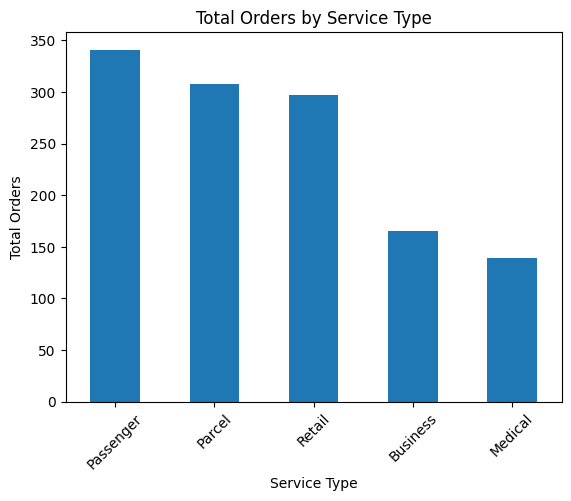

In [41]:
service_type_df.plot(
    x="_id",
    y="total_orders",
    kind="bar",
    legend=False
)

plt.title("Total Orders by Service Type")
plt.xlabel("Service Type")
plt.ylabel("Total Orders")
plt.xticks(rotation=45)
plt.show()

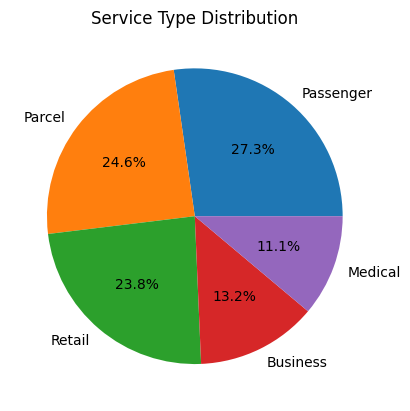

In [42]:
service_type_df.set_index("_id")["total_orders"].plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Service Type Distribution")
plt.ylabel("")
plt.show()

In [43]:
#Which service type has the most failed deliveries?
failed_service_data = list(collection.aggregate([
    {"$unwind": "$deliveries"},
    {
        "$group": {
            "_id": "$service_type",
            "failed_deliveries": {
                "$sum": {
                    "$cond": [
                        {"$eq": ["$deliveries.delivery_status", "Failed"]},
                        1,
                        0
                    ]
                }
            }
        }
    },
    {"$sort": {"failed_deliveries": -1}}
]))

failed_service_df = pd.DataFrame(failed_service_data)
failed_service_df

,_id,failed_deliveries
0,Passenger,38
1,Retail,28
2,Parcel,25
3,Business,25
4,Medical,16


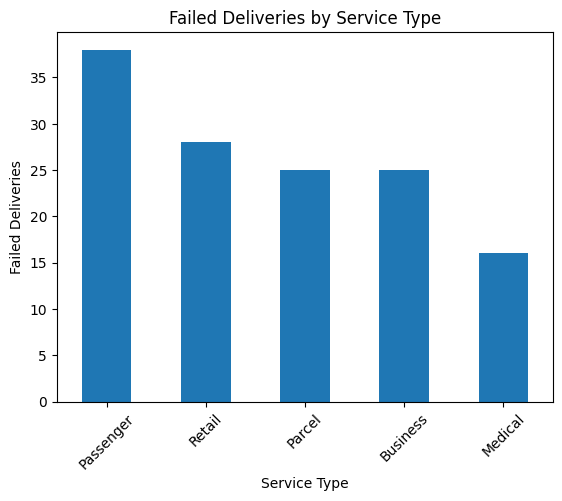

In [44]:
failed_service_df.plot(
    x="_id",
    y="failed_deliveries",
    kind="bar",
    legend=False
)

plt.title("Failed Deliveries by Service Type")
plt.xlabel("Service Type")
plt.ylabel("Failed Deliveries")
plt.xticks(rotation=45)
plt.show()

In [45]:
#Which complaint severity level appears most often?
complaint_severity_data = list(collection.aggregate([
    {"$unwind": "$complaints"},
    {
        "$group": {
            "_id": "$complaints.severity",
            "total_complaints": {"$sum": 1}
        }
    },
    {"$sort": {"total_complaints": -1}}
]))

complaint_severity_df = pd.DataFrame(complaint_severity_data)
complaint_severity_df

,_id,total_complaints
0,Medium,172
1,High,77
2,Low,71


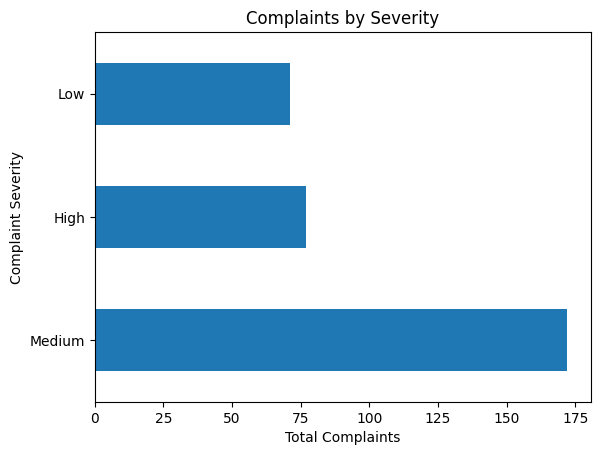

In [46]:
complaint_severity_df.plot(
    x="_id",
    y="total_complaints",
    kind="barh",
    legend=False
)

plt.title("Complaints by Severity")
plt.xlabel("Total Complaints")
plt.ylabel("Complaint Severity")
plt.show()

In [47]:
#Which complaint severity creates the highest compensation cost?
compensation_data = list(collection.aggregate([
    {"$unwind": "$complaints"},
    {
        "$group": {
            "_id": "$complaints.severity",
            "total_compensation": {"$sum": "$complaints.compensation_amount"}
        }
    },
    {"$sort": {"total_compensation": -1}}
]))

compensation_df = pd.DataFrame(compensation_data)
compensation_df

,_id,total_compensation
0,Medium,2882.61
1,High,2641.66
2,Low,633.92


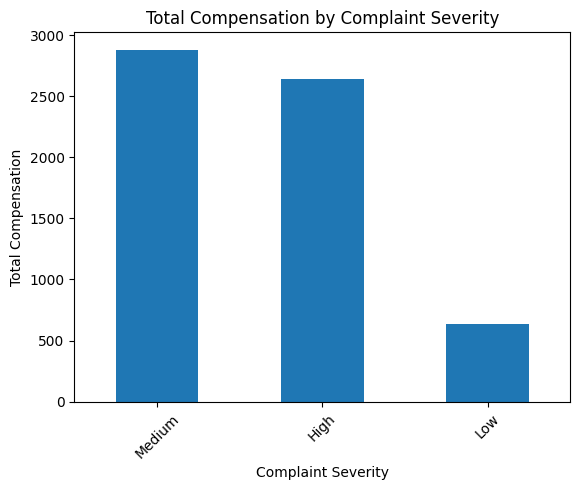

In [48]:
compensation_df.plot(
    x="_id",
    y="total_compensation",
    kind="bar",
    legend=False
)

plt.title("Total Compensation by Complaint Severity")
plt.xlabel("Complaint Severity")
plt.ylabel("Total Compensation")
plt.xticks(rotation=45)
plt.show()

In [49]:
#Do route overrides affect customer ratings?
override_rating_data = list(collection.aggregate([
    {"$unwind": "$deliveries"},
    {
        "$project": {
            "_id": 0,
            "manual_route_override_count": "$deliveries.manual_route_override_count",
            "customer_rating": "$deliveries.customer_rating_post_delivery"
        }
    }
]))

override_rating_df = pd.DataFrame(override_rating_data)
override_rating_df.head()

,manual_route_override_count,customer_rating
0,2,4.29
1,2,3.70
2,1,5.00
3,1,4.38
4,1,3.93


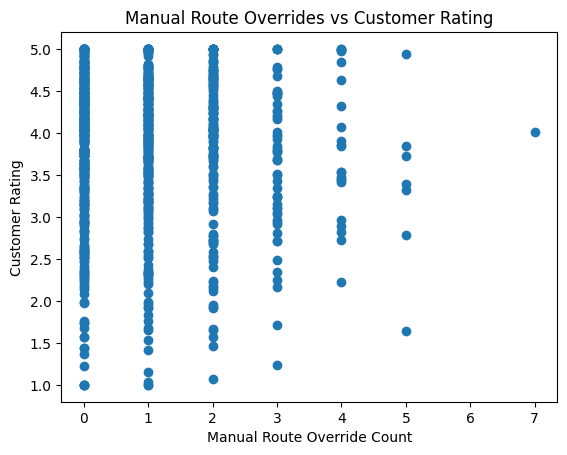

In [50]:
plt.scatter(
    override_rating_df["manual_route_override_count"],
    override_rating_df["customer_rating"]
)

plt.title("Manual Route Overrides vs Customer Rating")
plt.xlabel("Manual Route Override Count")
plt.ylabel("Customer Rating")
plt.show()

In [51]:
#What is the distribution of order values?
order_value_data = list(collection.find(
    {},
    {
        "_id": 0,
        "order_value": 1
    }
))

order_value_df = pd.DataFrame(order_value_data)
order_value_df.head()

,order_value
0,126.65
1,109.30
2,33.50
3,10.04
4,125.58


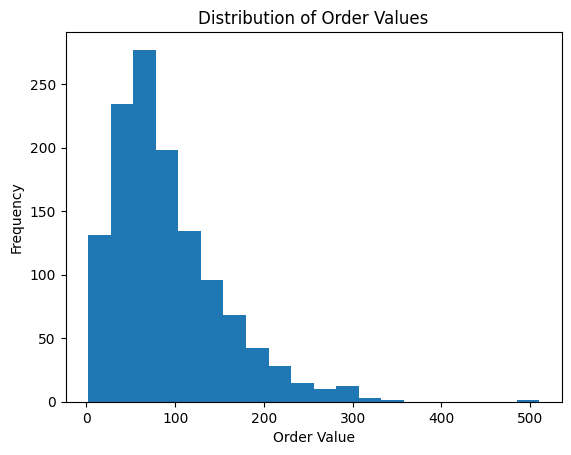

In [52]:
order_value_df["order_value"].plot(
    kind="hist",
    bins=20
)

plt.title("Distribution of Order Values")
plt.xlabel("Order Value")
plt.ylabel("Frequency")
plt.show()

In [53]:
#Which app event type has the highest failed event count?
app_failure_data = list(collection.aggregate([
    {"$unwind": "$app_events"},
    {
        "$group": {
            "_id": "$app_events.event_type",
            "total_events": {"$sum": 1},
            "failed_events": {
                "$sum": {
                    "$cond": [
                        {"$eq": ["$app_events.success_flag", 0]},
                        1,
                        0
                    ]
                }
            }
        }
    },
    {"$sort": {"failed_events": -1}}
]))

app_failure_df = pd.DataFrame(app_failure_data)
app_failure_df

,_id,total_events,failed_events
0,payment_retry,53,15
1,chat_escalated,29,14
2,eta_refresh,83,0
3,track_order,106,0
4,search_route,79,0
5,delivery_instruction_update,59,0
6,chat_opened,67,0
7,cancel_attempt,20,0


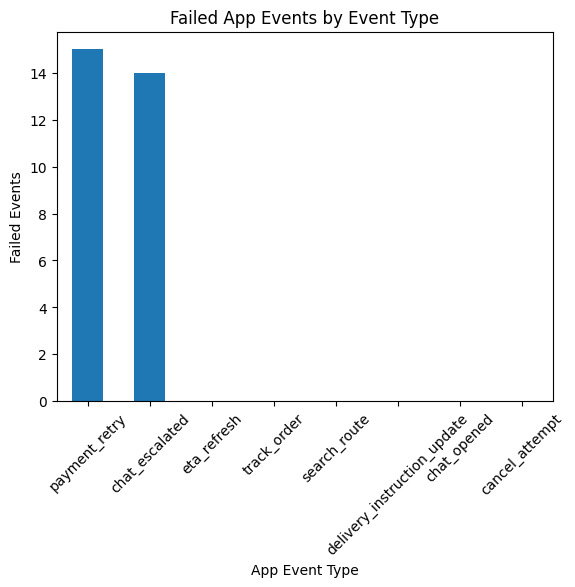

In [55]:
app_failure_df.plot(
    x="_id",
    y="failed_events",
    kind="bar",
    legend=False
)

plt.title("Failed App Events by Event Type")
plt.xlabel("App Event Type")
plt.ylabel("Failed Events")
plt.xticks(rotation=45)
plt.show()

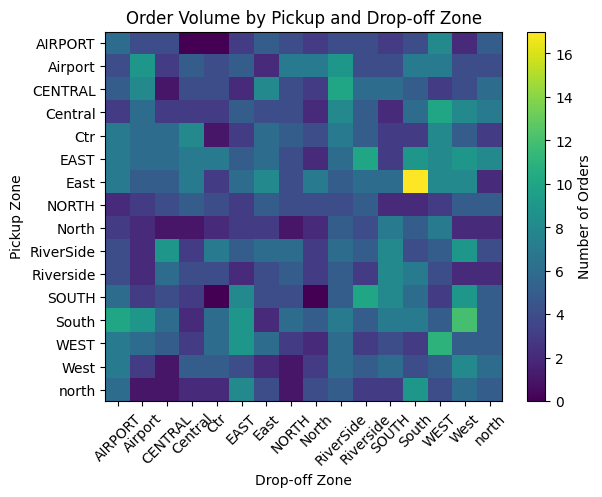

In [59]:
#Which pickup and drop-off zone combinations have the most orders?
zone_matrix = master.pivot_table(
    index="pickup_zone",
    columns="dropoff_zone",
    values="order_id",
    aggfunc="count",
    fill_value=0
)

plt.imshow(zone_matrix, aspect="auto")
plt.colorbar(label="Number of Orders")
plt.title("Order Volume by Pickup and Drop-off Zone")
plt.xlabel("Drop-off Zone")
plt.ylabel("Pickup Zone")
plt.xticks(range(len(zone_matrix.columns)), zone_matrix.columns, rotation=45)
plt.yticks(range(len(zone_matrix.index)), zone_matrix.index)
plt.show()

In [61]:
master["failed_flag"] = np.where(master["delivery_status"] == "Failed", 1, 0)

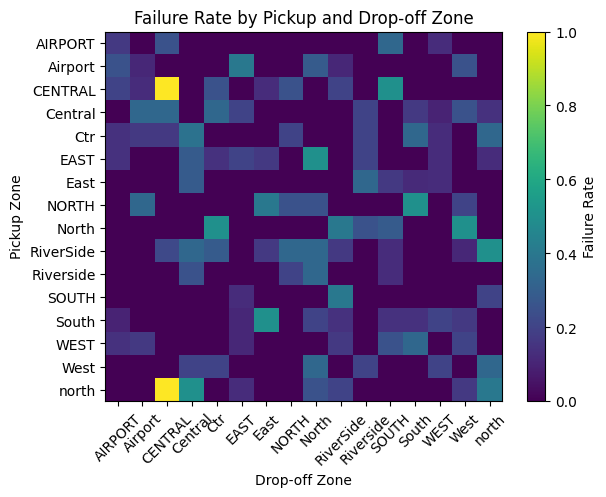

In [62]:
#Which pickup and drop-off zone combinations have the highest failure rate?
failure_matrix = master.pivot_table(
    index="pickup_zone",
    columns="dropoff_zone",
    values="failed_flag",
    aggfunc="mean",
    fill_value=0
)

plt.imshow(failure_matrix, aspect="auto")
plt.colorbar(label="Failure Rate")
plt.title("Failure Rate by Pickup and Drop-off Zone")
plt.xlabel("Drop-off Zone")
plt.ylabel("Pickup Zone")
plt.xticks(range(len(failure_matrix.columns)), failure_matrix.columns, rotation=45)
plt.yticks(range(len(failure_matrix.index)), failure_matrix.index)
plt.show()

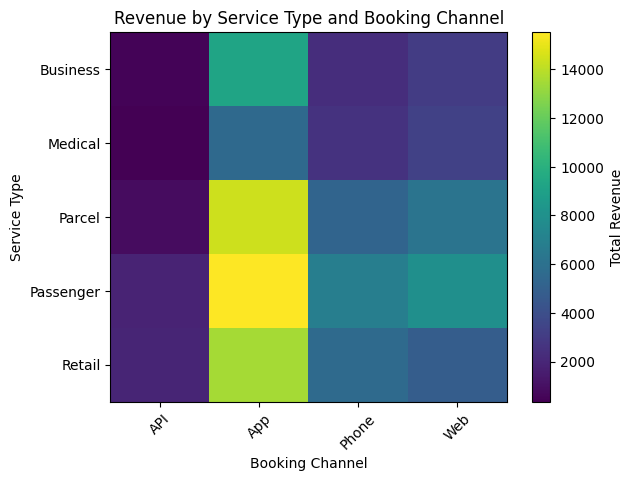

In [65]:
# Which service types and booking channels generate the highest revenue?
revenue_matrix = master.pivot_table(
    index="service_type",
    columns="booking_channel",
    values="order_value",
    aggfunc="sum",
    fill_value=0
)

plt.imshow(revenue_matrix, aspect="auto")
plt.colorbar(label="Total Revenue")
plt.title("Revenue by Service Type and Booking Channel")
plt.xlabel("Booking Channel")
plt.ylabel("Service Type")
plt.xticks(range(len(revenue_matrix.columns)), revenue_matrix.columns, rotation=45)
plt.yticks(range(len(revenue_matrix.index)), revenue_matrix.index)
plt.show()